Dataset Shape: (3525, 17)

================ MODEL PERFORMANCE ================

Random Forest
------------------------------
Train Accuracy : 97.49%
Validation Acc : 96.79%
Test Accuracy  : 95.46%
Precision      : 92.63%
Recall         : 96.26%
F1 Score       : 94.19%



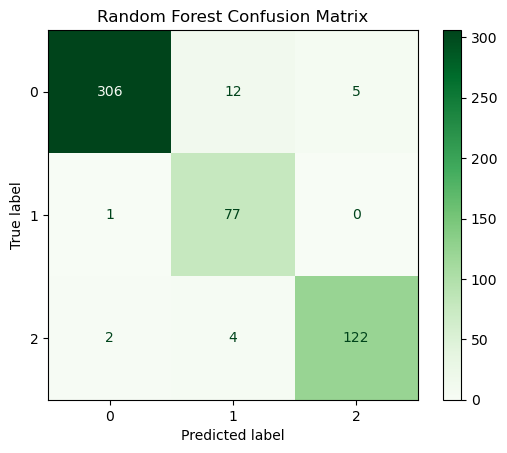

SVM
------------------------------
Train Accuracy : 98.54%
Validation Acc : 96.79%
Test Accuracy  : 96.03%
Precision      : 93.71%
Recall         : 96.72%
F1 Score       : 95.05%



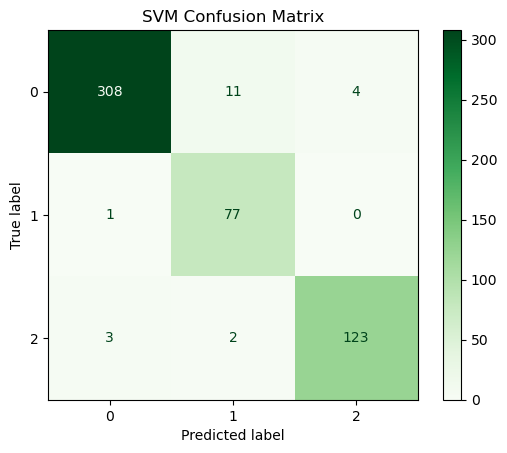

XGBoost
------------------------------
Train Accuracy : 99.96%
Validation Acc : 96.60%
Test Accuracy  : 96.22%
Precision      : 95.55%
Recall         : 95.70%
F1 Score       : 95.62%



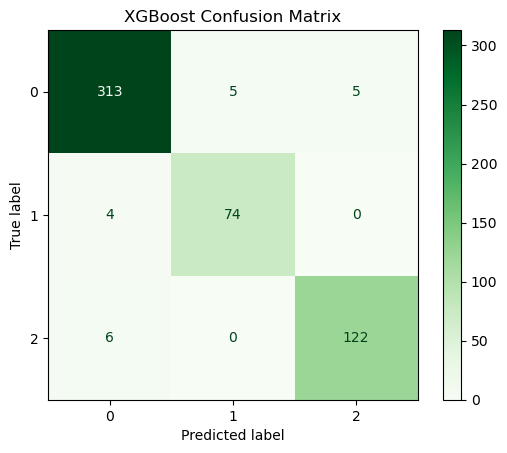


 Model,stable prediction 

 Stable model loaded → Predictions


In [ ]:
# ============================================================
# FINAL  CLASSIFICATION PROFESSIONAL VERSION CODE 
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import sys
import copy  

np.random.seed(42)  

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from PyQt5.QtWidgets import *
from PyQt5.QtGui import QFont
from PyQt5.QtCore import Qt

# ============================================================
# PATHS
# ============================================================

path = r"D:\priyadharsh project folder\Book3.xlsx"
save_path = r"C:\Users\Priyadharshini\Desktop\project model"
os.makedirs(save_path, exist_ok=True)

model_file = os.path.join(save_path,"model.pkl")
scaler_file = os.path.join(save_path,"scaler.pkl")
feature_file = os.path.join(save_path,"features.pkl")

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_excel(path)
print("Dataset Shape:", data.shape)

X = data.drop(columns=["Case Number", "Class Label"])
y = data["Class Label"]
feature_names = list(X.columns)

# ============================================================
# SPLIT (TRAIN,TEST,VALIDATION)
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# ============================================================
# SCALING FOR EVALUATION
# ============================================================

scaler_eval = StandardScaler()
X_train_s = scaler_eval.fit_transform(X_train)
X_val_s = scaler_eval.transform(X_val)
X_test_s = scaler_eval.transform(X_test)

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# ============================================================
# MODELS
# ============================================================

models = {
"Random Forest": RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=1   
),

"SVM": SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42
),

"XGBoost": XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=1   
)
}

best_model = None
best_acc = 0

print("\n================ MODEL PERFORMANCE ================\n")

for name, model in models.items():

    if name == "XGBoost":
        model.fit(X_train_s, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train_s, y_train)

    y_train_pred = model.predict(X_train_s)
    y_val_pred = model.predict(X_val_s)
    y_test_pred = model.predict(X_test_s)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    precision = precision_score(y_test, y_test_pred, average="macro")
    recall = recall_score(y_test, y_test_pred, average="macro")
    f1 = f1_score(y_test, y_test_pred, average="macro")

    print(name)
    print("------------------------------")
    print(f"Train Accuracy : {train_acc*100:.2f}%")
    print(f"Validation Acc : {val_acc*100:.2f}%")
    print(f"Test Accuracy  : {test_acc*100:.2f}%")
    print(f"Precision      : {precision*100:.2f}%")
    print(f"Recall         : {recall*100:.2f}%")
    print(f"F1 Score       : {f1*100:.2f}%\n")

    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Greens")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

       
    if test_acc > best_acc:
        best_acc = test_acc
        best_model = model

# ============================================================
# SELECT AND SAVE STABLE MODEL SYSTEM 
# ============================================================

def train_and_save():
    print("\nTraining and saving stable model...")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    final_model = copy.deepcopy(best_model)
    final_model.fit(X_scaled, y)

    joblib.dump(final_model, model_file)
    joblib.dump(scaler, scaler_file)
    joblib.dump(feature_names, feature_file)

if not os.path.exists(model_file):
    train_and_save()
else:
    saved_features = joblib.load(feature_file)
    if saved_features != feature_names:
        print("\n ERROR: Feature mismatch detected!")
        print("Please delete model.pkl, scaler.pkl, features.pkl manually and run again.")
        sys.exit()
    else:
        print("\n Model,stable prediction ")

# ============================================================
# LOAD STABLE MODEL
# ============================================================

model = joblib.load(model_file)
scaler = joblib.load(scaler_file)
feature_names = joblib.load(feature_file)

print("\n Stable model loaded → Predictions")

# ============================================================
# GUI 
# ============================================================

class GDMPredictor(QWidget):
    def __init__(self):
        super().__init__()

        self.setWindowTitle("GDM Prediction System")
        self.setGeometry(200,100,950,700)

        self.entries = {}
        layout = QVBoxLayout()

        title = QLabel("Gestational Diabetes Mellitus Prediction System")
        title.setFont(QFont("Segoe UI",20,QFont.Bold))
        title.setAlignment(Qt.AlignCenter)
        layout.addWidget(title)

        grid = QGridLayout()
        row,col = 0,0
        for f in feature_names:
            grid.addWidget(QLabel(f),row,col)
            entry = QLineEdit()
            grid.addWidget(entry,row,col+1)
            self.entries[f]=entry

            row+=1
            if row>8:
                row=0
                col+=2

        layout.addLayout(grid)
        list(self.entries.values())[0].installEventFilter(self)

        btn = QPushButton("Predict GDM Risk")
        btn.clicked.connect(self.predict)
        layout.addWidget(btn)

        reset = QPushButton("Reset")
        reset.clicked.connect(self.reset_fields)
        layout.addWidget(reset)

        self.result = QLabel("")
        self.result.setAlignment(Qt.AlignCenter)
        layout.addWidget(self.result)

        self.conf = QLabel("")
        self.conf.setAlignment(Qt.AlignCenter)
        layout.addWidget(self.conf)

        self.info = QTextEdit()
        self.info.setReadOnly(True)
        layout.addWidget(self.info)

        self.setLayout(layout)

    def predict(self):
        values = []
        for f in feature_names:
            val = self.entries[f].text()
            if val=="":
                QMessageBox.warning(self,"Error",f"Enter {f}")
                return
            values.append(float(val))

        df = pd.DataFrame([values],columns=feature_names)
        scaled = scaler.transform(df)

        pred = model.predict(scaled)
        prob = model.predict_proba(scaled)
        confidence = np.max(prob)*100

        label = int(pred[0])

        if label==0:
            text="Non-GDM"
            info="Healthy condition.\nMaintain diet, exercise, regular checkups."
        elif label==1:
            text="A1GDM"
            info="Mild diabetes.\nControl with diet and monitoring."
        else:
            text="A2GDM"
            info="High risk.\nRequires medical attention."

        self.result.setText(f"Prediction: {text}")
        self.conf.setText(f"Confidence: {confidence:.2f}%")
        self.info.setText(info)

    def reset_fields(self):
        for e in self.entries.values():
            e.clear()
        self.result.setText("")
        self.conf.setText("")
        self.info.clear()

    def handle_paste(self):
        try:
            data = QApplication.clipboard().text()
            values = data.strip().split("\t")
            for i, (f, entry) in enumerate(self.entries.items()):
                if i < len(values):
                    entry.setText(values[i])
        except Exception as e:
            print("Paste error:", e)

    def eventFilter(self, source, event):
        if event.type() == event.KeyPress:
            if event.modifiers() == Qt.ControlModifier and event.key() == Qt.Key_V:
                self.handle_paste()
                return True
        return super().eventFilter(source, event)

# ============================================================
# RUN
# ============================================================

app = QApplication(sys.argv)
w = GDMPredictor()
w.show()
sys.exit(app.exec_())